Step 1: Sparse Poisson Factor Model - Basic Poisson NLL Optimization
=====================================================================
Goal: Learn Λ (basis patterns) and α (mixing weights) from observed spike counts Y
      by minimizing the Poisson negative log-likelihood using gradient descent.

Model: y_ni ~ Poisson(r_ni), where r_ni = Σ_k λ_nk · α_ik

In [24]:
import jax
import jax.numpy as jnp
from jax import grad, jit
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

In [25]:
# Enable 64-bit precision for numerical stability
jax.config.update("jax_enable_x64", True)

# 1. LOAD SYNTHETIC DATA

In [26]:
def load_data(filepath):
    """Load the generated synthetic data."""
    data = np.load(filepath)
    Y = data['Y']           # Observed spikes: (N, M) = (20, 50)
    Alphas_true = data['Alphas']   # Ground truth mixing weights: (K, M) = (3, 50)
    Lambdas_true = data['Lambdas'] # Ground truth basis patterns: (N, K) = (20, 3)
    return Y, Alphas_true, Lambdas_true

# 2. MODEL DEFINITION

In [27]:
def softplus(x):
    """Softplus: maps R -> R+ (ensures non-negativity)."""
    return jnp.log(1 + jnp.exp(x))

In [28]:
def compute_rates(params):
    """
    Compute expected firing rates: R = Λ · α
    
    params: dict with 'lambda_raw' (N, K) and 'alpha_raw' (K, M)
    returns: R (N, M) - expected rates for each neuron at each timepoint
    """
    # Apply softplus to ensure non-negativity
    Lambda = softplus(params['lambda_raw'])  # (N, K)
    Alpha = softplus(params['alpha_raw'])    # (K, M)
    
    # R = Λ · α  -> (N, K) @ (K, M) = (N, M)
    R = Lambda @ Alpha
    
    # Add small epsilon for numerical stability (avoid log(0))
    R = R + 1e-8
    
    return R, Lambda, Alpha

In [29]:
def poisson_nll(params, Y):
    """
    Poisson Negative Log-Likelihood.
    
    NLL = Σ_i Σ_n [r_ni - y_ni · log(r_ni)]
    
    (We drop the log(y!) constant since it doesn't affect optimization)
    """
    R, _, _ = compute_rates(params)
    
    # Poisson NLL: sum of (r - y*log(r))
    nll = jnp.sum(R - Y * jnp.log(R))
    
    return nll

# 3. INITIALIZATION

In [30]:
def initialize_params(N, K, M, seed=0):
    """Initialize raw (unconstrained) parameters randomly."""
    key = jax.random.PRNGKey(seed)
    key1, key2 = jax.random.split(key)
    
    # Initialize in unconstrained space (will be mapped through softplus)
    # Small positive values so softplus(x) starts reasonable
    lambda_raw = jax.random.uniform(key1, (N, K), minval=0.5, maxval=2.0)
    alpha_raw = jax.random.uniform(key2, (K, M), minval=-1.0, maxval=1.0)
    
    return {
        'lambda_raw': lambda_raw,
        'alpha_raw': alpha_raw
    }

# 4. GRADIENT DESCENT

In [31]:
@jit
def update_step(params, Y, learning_rate):
    """Single gradient descent update."""
    loss, grads = jax.value_and_grad(poisson_nll)(params, Y)
    
    # Update parameters
    new_params = {
        'lambda_raw': params['lambda_raw'] - learning_rate * grads['lambda_raw'],
        'alpha_raw': params['alpha_raw'] - learning_rate * grads['alpha_raw']
    }
    
    return new_params, loss


def fit_model(Y, K, n_iters=2000, learning_rate=0.01, print_every=200):
    """
    Fit the Sparse Poisson Factor Model via gradient descent.
    
    Args:
        Y: observed spike counts (N, M)
        K: number of motifs/components
        n_iters: number of gradient descent iterations
        learning_rate: step size
    
    Returns:
        params: fitted parameters
        losses: loss history
    """
    N, M = Y.shape
    Y_jax = jnp.array(Y)
    
    # Initialize
    params = initialize_params(N, K, M)
    losses = []
    
    print(f"Fitting model: N={N} neurons, K={K} motifs, M={M} samples")
    print(f"Parameters to learn: Λ ({N}x{K}) + α ({K}x{M}) = {N*K + K*M} total")
    print("-" * 50)
    
    for i in range(n_iters):
        params, loss = update_step(params, Y_jax, learning_rate)
        losses.append(float(loss))
        
        if (i + 1) % print_every == 0:
            print(f"Iter {i+1:4d} | Loss: {loss:.2f}")
    
    return params, losses

# 5. EVALUATION

In [32]:
def evaluate_recovery(params, Lambdas_true, Alphas_true):
    """
    Compare recovered parameters to ground truth.
    
    Note: There's a scale ambiguity (Λ·α = (Λ·c)·(α/c)), 
    and permutation ambiguity (motif ordering).
    We'll use correlation to assess recovery.
    """
    _, Lambda_fit, Alpha_fit = compute_rates(params)
    Lambda_fit = np.array(Lambda_fit)
    Alpha_fit = np.array(Alpha_fit)
    
    K = Lambda_fit.shape[1]
    
    print("\n" + "=" * 50)
    print("RECOVERY ANALYSIS")
    print("=" * 50)
    
    # For each true motif, find best matching fitted motif
    print("\nΛ (Basis Patterns) - Correlation with ground truth:")
    for k_true in range(K):
        correlations = []
        for k_fit in range(K):
            corr = np.corrcoef(Lambdas_true[:, k_true], Lambda_fit[:, k_fit])[0, 1]
            correlations.append(corr)
        best_match = np.argmax(np.abs(correlations))
        print(f"  True motif {k_true} <-> Fitted motif {best_match}: r = {correlations[best_match]:.3f}")
    
    print("\nα (Mixing Weights) - Correlation with ground truth:")
    for k_true in range(Alphas_true.shape[0]):
        correlations = []
        for k_fit in range(K):
            corr = np.corrcoef(Alphas_true[k_true, :], Alpha_fit[k_fit, :])[0, 1]
            correlations.append(corr)
        best_match = np.argmax(np.abs(correlations))
        print(f"  True motif {k_true} <-> Fitted motif {best_match}: r = {correlations[best_match]:.3f}")
    
    # Reconstruction error
    R_fit = Lambda_fit @ Alpha_fit
    R_true = Lambdas_true @ Alphas_true
    recon_corr = np.corrcoef(R_fit.flatten(), R_true.flatten())[0, 1]
    print(f"\nReconstruction correlation (fitted rates vs true rates): {recon_corr:.4f}")
    
    return Lambda_fit, Alpha_fit

In [33]:
def plot_results(Y, params, Lambdas_true, Alphas_true, losses):
    """Visualize fitting results."""
    _, Lambda_fit, Alpha_fit = compute_rates(params)
    Lambda_fit = np.array(Lambda_fit)
    Alpha_fit = np.array(Alpha_fit)
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    
    # 1. Loss curve
    axes[0, 0].plot(losses, color='blue', linewidth=2)
    axes[0, 0].set_xlabel('Iteration')
    axes[0, 0].set_ylabel('Poisson NLL')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. True Λ
    im1 = axes[0, 1].imshow(Lambdas_true, aspect='auto', cmap='viridis')
    axes[0, 1].set_xlabel('Motif')
    axes[0, 1].set_ylabel('Neuron')
    axes[0, 1].set_title('True Λ (Basis Patterns)')
    plt.colorbar(im1, ax=axes[0, 1])
    
    # 3. Fitted Λ
    im2 = axes[0, 2].imshow(Lambda_fit, aspect='auto', cmap='viridis')
    axes[0, 2].set_xlabel('Motif')
    axes[0, 2].set_ylabel('Neuron')
    axes[0, 2].set_title('Fitted Λ (Basis Patterns)')
    plt.colorbar(im2, ax=axes[0, 2])
    
    # 4. True α
    im3 = axes[1, 0].imshow(Alphas_true, aspect='auto', cmap='plasma')
    axes[1, 0].set_xlabel('Time Sample')
    axes[1, 0].set_ylabel('Motif')
    axes[1, 0].set_title('True α (Mixing Weights)')
    plt.colorbar(im3, ax=axes[1, 0])
    
    # 5. Fitted α
    im4 = axes[1, 1].imshow(Alpha_fit, aspect='auto', cmap='plasma')
    axes[1, 1].set_xlabel('Time Sample')
    axes[1, 1].set_ylabel('Motif')
    axes[1, 1].set_title('Fitted α (Mixing Weights)')
    plt.colorbar(im4, ax=axes[1, 1])
    
    # 6. Reconstruction comparison
    R_fit = Lambda_fit @ Alpha_fit
    R_true = Lambdas_true @ Alphas_true
    axes[1, 2].scatter(R_true.flatten(), R_fit.flatten(), alpha=0.5, s=10)
    max_val = max(R_true.max(), R_fit.max())
    axes[1, 2].plot([0, max_val], [0, max_val], 'r--', label='Perfect recovery')
    axes[1, 2].set_xlabel('True Rates')
    axes[1, 2].set_ylabel('Fitted Rates')
    axes[1, 2].set_title('Rate Reconstruction')
    axes[1, 2].legend()
    
    plt.tight_layout()
    plt.savefig('step1_results.png', dpi=150)
    plt.show()
    print("\nPlot saved to 'step1_results.png'")

# 6. EXECUTION

Loaded data shapes:
  Y (observed):     (20, 50)
  Alphas (true):    (3, 50)
  Lambdas (true):   (20, 3)

Fitting model: N=20 neurons, K=3 motifs, M=50 samples
Parameters to learn: Λ (20x3) + α (3x50) = 210 total
--------------------------------------------------


Iter  200 | Loss: -12763.40
Iter  400 | Loss: -12865.67
Iter  600 | Loss: -12872.82
Iter  800 | Loss: -12875.20
Iter 1000 | Loss: -12876.46
Iter 1200 | Loss: -12877.28
Iter 1400 | Loss: -12877.86
Iter 1600 | Loss: -12878.29
Iter 1800 | Loss: -12878.62
Iter 2000 | Loss: -12878.88
Iter 2200 | Loss: -12879.09
Iter 2400 | Loss: -12879.26
Iter 2600 | Loss: -12879.41
Iter 2800 | Loss: -12879.52
Iter 3000 | Loss: -12879.62

RECOVERY ANALYSIS

Λ (Basis Patterns) - Correlation with ground truth:
  True motif 0 <-> Fitted motif 2: r = 0.688
  True motif 1 <-> Fitted motif 0: r = 0.873
  True motif 2 <-> Fitted motif 1: r = 0.873

α (Mixing Weights) - Correlation with ground truth:
  True motif 0 <-> Fitted motif 0: r = -0.800
  True motif 1 <-> Fitted motif 1: r = -0.933
  True motif 2 <-> Fitted motif 2: r = -0.885

Reconstruction correlation (fitted rates vs true rates): 0.9621


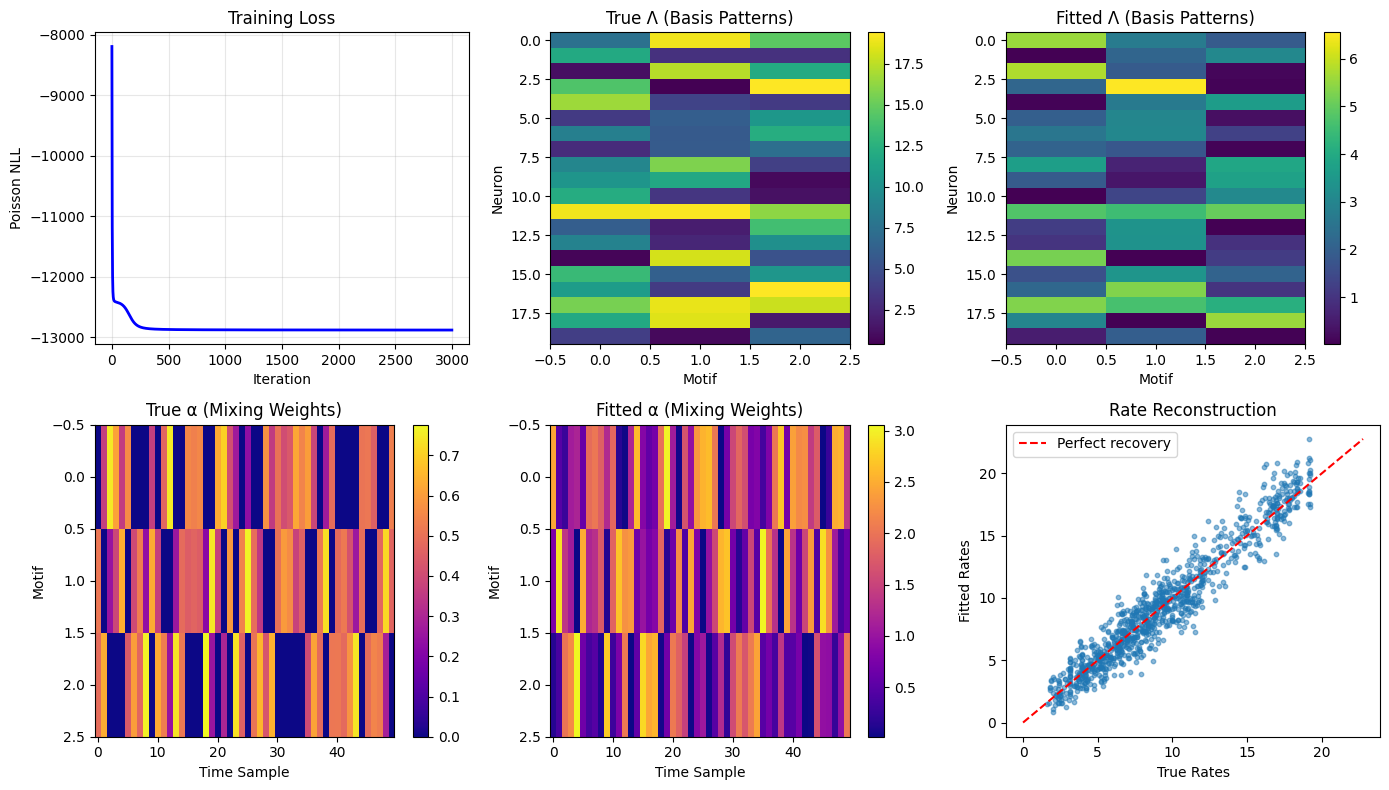


Plot saved to 'step1_results.png'


In [34]:
if __name__ == "__main__":
    # Load your data
    Y, Alphas_true, Lambdas_true = load_data("../gendata/simNeural.npz")
    
    print(f"Loaded data shapes:")
    print(f"  Y (observed):     {Y.shape}")
    print(f"  Alphas (true):    {Alphas_true.shape}")
    print(f"  Lambdas (true):   {Lambdas_true.shape}")
    print()
    
    # Fit the model
    K = 3  # Number of motifs (we know this for synthetic data)
    params, losses = fit_model(Y, K, n_iters=3000, learning_rate=0.005)
    
    # Evaluate recovery
    Lambda_fit, Alpha_fit = evaluate_recovery(params, Lambdas_true, Alphas_true)
    
    # Visualize
    plot_results(Y, params, Lambdas_true, Alphas_true, losses)


# Step 2

In [35]:
# NEW: Add this function
def sparse_loss(params, Y, beta):
    """Poisson NLL + L1 sparsity penalty."""
    R, Lambda, Alpha = compute_rates(params)
    nll = jnp.sum(R - Y * jnp.log(R))
    l1_penalty = beta * jnp.sum(Alpha)
    return nll + l1_penalty

In [36]:
@jit
def update_step(params, Y, beta, learning_rate):  # Added beta
    loss, grads = jax.value_and_grad(sparse_loss)(params, Y, beta)  # Changed to sparse_loss
    
    new_params = {
        'lambda_raw': params['lambda_raw'] - learning_rate * grads['lambda_raw'],
        'alpha_raw': params['alpha_raw'] - learning_rate * grads['alpha_raw']
    }
    
    return new_params, loss


def fit_model(Y, K, beta=1.0, n_iters=3000, learning_rate=0.01, print_every=200):  # Added beta
    N, M = Y.shape
    Y_jax = jnp.array(Y)
    
    params = initialize_params(N, K, M)
    losses = []
    
    print(f"Fitting Sparse Poisson Factor Model")
    print(f"  N={N} neurons, K={K} motifs, M={M} samples")
    print(f"  Sparsity penalty β = {beta}")
    print("-" * 50)
    
    for i in range(n_iters):
        params, loss = update_step(params, Y_jax, beta, learning_rate)  # Added beta
        losses.append(float(loss))
        
        if (i + 1) % print_every == 0:
            _, _, Alpha = compute_rates(params)
            sparsity = float(jnp.mean(Alpha < 0.1))  # Track sparsity
            print(f"Iter {i+1:4d} | Loss: {loss:10.2f} | α sparsity: {sparsity:.2%}")
    
    return params, losses

In [37]:
def evaluate_recovery(params, Lambdas_true, Alphas_true):
    _, Lambda_fit, Alpha_fit = compute_rates(params)
    Lambda_fit = np.array(Lambda_fit)
    Alpha_fit = np.array(Alpha_fit)
    
    K = Lambda_fit.shape[1]
    
    print("\n" + "=" * 50)
    print("RECOVERY ANALYSIS")
    print("=" * 50)
    
    print("\nΛ (Basis Patterns) - Correlation with ground truth:")
    for k_true in range(K):
        correlations = []
        for k_fit in range(K):
            corr = np.corrcoef(Lambdas_true[:, k_true], Lambda_fit[:, k_fit])[0, 1]
            correlations.append(corr)
        best_match = np.argmax(np.abs(correlations))
        print(f"  True motif {k_true} <-> Fitted motif {best_match}: r = {correlations[best_match]:.3f}")
    
    print("\nα (Mixing Weights) - Correlation with ground truth:")
    for k_true in range(Alphas_true.shape[0]):
        correlations = []
        for k_fit in range(K):
            corr = np.corrcoef(Alphas_true[k_true, :], Alpha_fit[k_fit, :])[0, 1]
            correlations.append(corr)
        best_match = np.argmax(np.abs(correlations))
        print(f"  True motif {k_true} <-> Fitted motif {best_match}: r = {correlations[best_match]:.3f}")
    
    R_fit = Lambda_fit @ Alpha_fit
    R_true = Lambdas_true @ Alphas_true
    recon_corr = np.corrcoef(R_fit.flatten(), R_true.flatten())[0, 1]
    print(f"\nReconstruction correlation: {recon_corr:.4f}")
    
    # NEW: Sparsity comparison
    true_sparsity = np.mean(Alphas_true < 0.01)
    fit_sparsity = np.mean(Alpha_fit < 0.1)
    print(f"\nSparsity (fraction near-zero):")
    print(f"  True α:   {true_sparsity:.2%}")
    print(f"  Fitted α: {fit_sparsity:.2%}")
    
    return Lambda_fit, Alpha_fit

In [38]:
def plot_results(Y, params, Lambdas_true, Alphas_true, losses, beta):  # Added beta
    _, Lambda_fit, Alpha_fit = compute_rates(params)
    Lambda_fit = np.array(Lambda_fit)
    Alpha_fit = np.array(Alpha_fit)
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f'Sparse Poisson Factor Model (β = {beta})', fontsize=14)
    
    # 1. Loss curve - FIXED: removed log scale
    axes[0, 0].plot(losses)
    axes[0, 0].set_xlabel('Iteration')
    axes[0, 0].set_ylabel('Loss (NLL + L1)')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].grid(True, alpha=0.3)  # Changed from set_yscale('log')
    
    # 2-6: Same as before
    im1 = axes[0, 1].imshow(Lambdas_true, aspect='auto', cmap='viridis')
    axes[0, 1].set_xlabel('Motif')
    axes[0, 1].set_ylabel('Neuron')
    axes[0, 1].set_title('True Λ')
    plt.colorbar(im1, ax=axes[0, 1])
    
    im2 = axes[0, 2].imshow(Lambda_fit, aspect='auto', cmap='viridis')
    axes[0, 2].set_xlabel('Motif')
    axes[0, 2].set_ylabel('Neuron')
    axes[0, 2].set_title('Fitted Λ')
    plt.colorbar(im2, ax=axes[0, 2])
    
    im3 = axes[1, 0].imshow(Alphas_true, aspect='auto', cmap='plasma')
    axes[1, 0].set_xlabel('Time Sample')
    axes[1, 0].set_ylabel('Motif')
    axes[1, 0].set_title('True α')
    plt.colorbar(im3, ax=axes[1, 0])
    
    im4 = axes[1, 1].imshow(Alpha_fit, aspect='auto', cmap='plasma')
    axes[1, 1].set_xlabel('Time Sample')
    axes[1, 1].set_ylabel('Motif')
    axes[1, 1].set_title('Fitted α')
    plt.colorbar(im4, ax=axes[1, 1])
    
    R_fit = Lambda_fit @ Alpha_fit
    R_true = Lambdas_true @ Alphas_true
    axes[1, 2].scatter(R_true.flatten(), R_fit.flatten(), alpha=0.5, s=10)
    max_val = max(R_true.max(), R_fit.max())
    axes[1, 2].plot([0, max_val], [0, max_val], 'r--', label='Perfect')
    axes[1, 2].set_xlabel('True Rates')
    axes[1, 2].set_ylabel('Fitted Rates')
    axes[1, 2].set_title('Rate Reconstruction')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Fitting Sparse Poisson Factor Model
  N=20 neurons, K=3 motifs, M=50 samples
  Sparsity penalty β = 5.0
--------------------------------------------------


Iter  200 | Loss:  -12145.29 | α sparsity: 0.00%
Iter  400 | Loss:  -12401.20 | α sparsity: 10.67%
Iter  600 | Loss:  -12471.34 | α sparsity: 16.67%
Iter  800 | Loss:  -12512.66 | α sparsity: 18.67%
Iter 1000 | Loss:  -12541.32 | α sparsity: 20.00%
Iter 1200 | Loss:  -12562.85 | α sparsity: 20.00%
Iter 1400 | Loss:  -12579.87 | α sparsity: 22.00%
Iter 1600 | Loss:  -12593.79 | α sparsity: 22.00%
Iter 1800 | Loss:  -12605.48 | α sparsity: 22.67%
Iter 2000 | Loss:  -12615.50 | α sparsity: 22.67%
Iter 2200 | Loss:  -12624.21 | α sparsity: 24.00%
Iter 2400 | Loss:  -12631.89 | α sparsity: 24.00%
Iter 2600 | Loss:  -12638.74 | α sparsity: 24.00%
Iter 2800 | Loss:  -12644.90 | α sparsity: 24.00%
Iter 3000 | Loss:  -12650.48 | α sparsity: 24.67%

RECOVERY ANALYSIS

Λ (Basis Patterns) - Correlation with ground truth:
  True motif 0 <-> Fitted motif 2: r = 0.618
  True motif 1 <-> Fitted motif 0: r = 0.814
  True motif 2 <-> Fitted motif 1: r = 0.832

α (Mixing Weights) - Correlation with groun

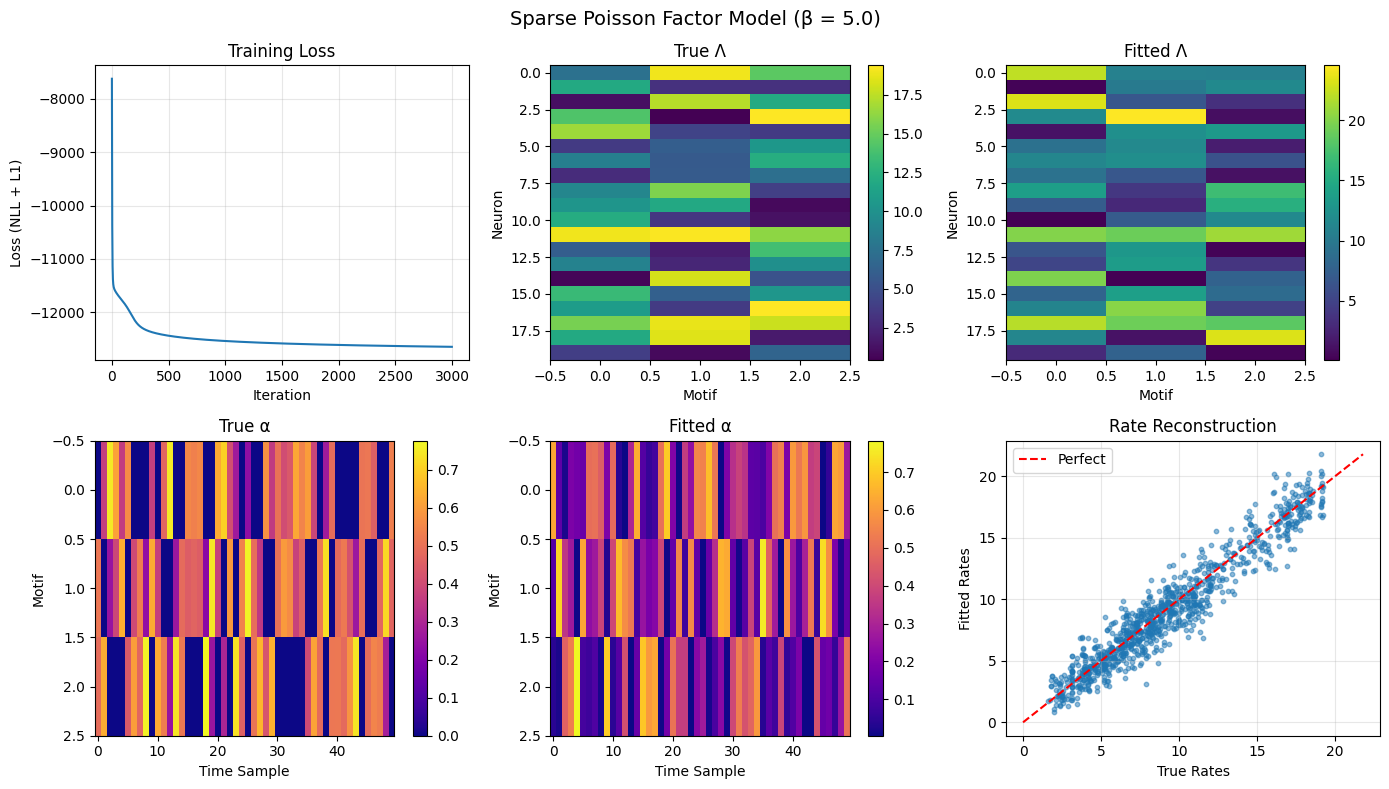

In [39]:
# Load data
Y, Alphas_true, Lambdas_true = load_data("../gendata/simNeural.npz")

# Settings
K = 3
beta = 5.0  # Sparsity weight - tune this

# Fit
params, losses = fit_model(Y, K, beta=beta, n_iters=3000, learning_rate=0.005)

# Evaluate
Lambda_fit, Alpha_fit = evaluate_recovery(params, Lambdas_true, Alphas_true)


print("\nFitted Λ (rounded):")
print(np.round(Lambda_fit, 2))

print("\nFitted α (rounded):")
print(np.round(Alpha_fit, 2))


# Plot
plot_results(Y, params, Lambdas_true, Alphas_true, losses, beta)

Step 3: Improved Sparse Poisson Factor Model
=============================================
Two improvements:
1. Alignment: Match fitted motifs to true motifs (fixes permutation/scale ambiguity)
2. L1 Constraint: Projected gradient descent onto simplex (true sparsity)

In [40]:
# =============================================================================
# SOLUTION 1: ALIGNMENT (fixes permutation & scale ambiguity)
# =============================================================================

def align_factors(Lambda_fit, Alpha_fit, Lambdas_true, Alphas_true):
    """
    Align fitted factors to true factors using Hungarian algorithm.
    Fixes permutation ambiguity and rescales for fair comparison.
    
    Returns aligned (reordered) Lambda_fit and Alpha_fit
    """
    K = Lambda_fit.shape[1]
    
    # Build cost matrix based on correlation (negative because we want to maximize)
    cost_matrix = np.zeros((K, K))
    for k_true in range(K):
        for k_fit in range(K):
            # Correlation between Lambda columns
            corr_lambda = np.corrcoef(Lambdas_true[:, k_true], Lambda_fit[:, k_fit])[0, 1]
            # Correlation between Alpha rows
            corr_alpha = np.corrcoef(Alphas_true[k_true, :], Alpha_fit[k_fit, :])[0, 1]
            # Combined score (use absolute value since sign can flip)
            cost_matrix[k_true, k_fit] = -(np.abs(corr_lambda) + np.abs(corr_alpha))
    
    # Hungarian algorithm finds optimal matching
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Reorder fitted factors to match true ordering
    Lambda_aligned = Lambda_fit[:, col_ind]
    Alpha_aligned = Alpha_fit[col_ind, :]
    
    print("Motif alignment (true -> fitted):", dict(zip(row_ind, col_ind)))
    
    return Lambda_aligned, Alpha_aligned, col_ind

In [41]:
# =============================================================================
# SOLUTION 2: L1 CONSTRAINT VIA PROJECTED GRADIENT DESCENT
# =============================================================================

def softplus(x):
    return jnp.log(1 + jnp.exp(x))

def softplus_inverse(y):
    """Inverse of softplus for initialization."""
    return jnp.log(jnp.exp(y) - 1 + 1e-8)


def project_simplex(v, z=1.0):
    """
    Project vector v onto the simplex {x : x >= 0, sum(x) <= z}.
    This is the KEY operation for L1 constraint.
    
    Based on: https://arxiv.org/abs/1309.1541
    """
    n = len(v)
    u = jnp.sort(v)[::-1]  # sort descending
    cssv = jnp.cumsum(u)
    rho = jnp.sum(u * jnp.arange(1, n + 1) > (cssv - z)) - 1
    theta = (cssv[rho] - z) / (rho + 1)
    return jnp.maximum(v - theta, 0)


def project_alpha_to_simplex(Alpha, max_l1_per_sample=1.0):
    """
    Project each column of Alpha onto the simplex.
    This enforces: alpha_i >= 0 and ||alpha_i||_1 <= max_l1_per_sample
    """
    # Project each sample (column) independently
    Alpha_projected = jax.vmap(lambda col: project_simplex(col, max_l1_per_sample), in_axes=1, out_axes=1)(Alpha)
    return Alpha_projected


def compute_rates_direct(Lambda, Alpha):
    """Compute rates directly from non-negative parameters."""
    R = Lambda @ Alpha + 1e-8
    return R


def poisson_nll_direct(Lambda, Alpha, Y):
    """Poisson NLL with direct (non-negative) parameters."""
    R = compute_rates_direct(Lambda, Alpha)
    return jnp.sum(R - Y * jnp.log(R))

# Gradients w.r.t. Lambda and Alpha separately
grad_lambda = jit(grad(poisson_nll_direct, argnums=0))
grad_alpha = jit(grad(poisson_nll_direct, argnums=1))

In [42]:
def fit_model_projected(Y, K, max_l1=1.1, n_iters=5000, lr=0.05, print_every=200):
    """
    Fit using PROJECTED gradient descent.
    
    Instead of: min NLL + β·||α||₁  (penalty)
    We do:      min NLL  subject to ||α||₁ ≤ max_l1  (constraint)
    
    This achieves EXACT zeros via simplex projection.
    """
    N, M = Y.shape
    Y_jax = jnp.array(Y)
    
    # Initialize (non-negative)
    key = jax.random.PRNGKey(42)
    key1, key2 = jax.random.split(key)
    Lambda = jax.random.uniform(key1, (N, K), minval=1.0, maxval=10.0)
    Alpha = jax.random.uniform(key2, (K, M), minval=0.1, maxval=0.5)
    
    # Normalize Alpha to satisfy constraint initially
    Alpha = project_alpha_to_simplex(Alpha, max_l1)
    
    losses = []
    
    print(f"Fitting with PROJECTED Gradient Descent")
    print(f"  N={N}, K={K}, M={M}")
    print(f"  L1 constraint: ||α||₁ ≤ {max_l1} per sample")
    print("-" * 50)
    
    for i in range(n_iters):
        # Compute gradients
        g_lambda = grad_lambda(Lambda, Alpha, Y_jax)
        g_alpha = grad_alpha(Lambda, Alpha, Y_jax)
        
        # Gradient step
        Lambda = Lambda - lr * g_lambda
        Alpha = Alpha - lr * g_alpha
        
        # Project onto constraints
        Lambda = jnp.maximum(Lambda, 1e-8)  # Non-negativity for Lambda
        Alpha = project_alpha_to_simplex(Alpha, max_l1)  # Simplex constraint for Alpha
        
        # Track loss
        loss = float(poisson_nll_direct(Lambda, Alpha, Y_jax))
        losses.append(loss)
        
        if (i + 1) % print_every == 0:
            sparsity = float(jnp.mean(Alpha < 0.01))
            exact_zeros = float(jnp.mean(Alpha == 0))
            print(f"Iter {i+1:4d} | Loss: {loss:10.2f} | Sparsity (<0.01): {sparsity:.2%} | Exact zeros: {exact_zeros:.2%}")
    
    return Lambda, Alpha, losses

In [43]:
# =============================================================================
# ORIGINAL PENALTY-BASED METHOD (for comparison)
# =============================================================================

def compute_rates(params):
    Lambda = softplus(params['lambda_raw'])
    Alpha = softplus(params['alpha_raw'])
    R = Lambda @ Alpha + 1e-8
    return R, Lambda, Alpha


def sparse_loss(params, Y, beta):
    R, Lambda, Alpha = compute_rates(params)
    nll = jnp.sum(R - Y * jnp.log(R))
    l1_penalty = beta * jnp.sum(Alpha)
    return nll + l1_penalty


@jit
def update_step_penalty(params, Y, beta, lr):
    loss, grads = jax.value_and_grad(sparse_loss)(params, Y, beta)
    new_params = {
        'lambda_raw': params['lambda_raw'] - lr * grads['lambda_raw'],
        'alpha_raw': params['alpha_raw'] - lr * grads['alpha_raw']
    }
    return new_params, loss


def fit_model_penalty(Y, K, beta=5.0, n_iters=3000, lr=0.005, print_every=200):
    """Original penalty-based method."""
    N, M = Y.shape
    Y_jax = jnp.array(Y)
    
    key = jax.random.PRNGKey(42)
    key1, key2 = jax.random.split(key)
    params = {
        'lambda_raw': jax.random.uniform(key1, (N, K), minval=0.5, maxval=2.0),
        'alpha_raw': jax.random.uniform(key2, (K, M), minval=-1.0, maxval=1.0)
    }
    
    losses = []
    
    print(f"Fitting with L1 PENALTY (β={beta})")
    print("-" * 50)
    
    for i in range(n_iters):
        params, loss = update_step_penalty(params, Y_jax, beta, lr)
        losses.append(float(loss))
        
        if (i + 1) % print_every == 0:
            _, _, Alpha = compute_rates(params)
            sparsity = float(jnp.mean(Alpha < 0.01))
            exact_zeros = float(jnp.mean(Alpha == 0))
            print(f"Iter {i+1:4d} | Loss: {loss:10.2f} | Sparsity (<0.01): {sparsity:.2%} | Exact zeros: {exact_zeros:.2%}")
    
    _, Lambda, Alpha = compute_rates(params)
    return np.array(Lambda), np.array(Alpha), losses

In [44]:
# =============================================================================
# EVALUATION
# =============================================================================

def evaluate(Lambda_fit, Alpha_fit, Lambdas_true, Alphas_true, method_name=""):
    """Comprehensive evaluation with alignment."""
    
    print(f"\n{'='*60}")
    print(f"EVALUATION: {method_name}")
    print('='*60)
    
    # Align first
    Lambda_aligned, Alpha_aligned, matching = align_factors(
        Lambda_fit, Alpha_fit, Lambdas_true, Alphas_true
    )
    
    K = Lambda_fit.shape[1]
    
    # Lambda correlations (after alignment)
    print("\nΛ correlations (aligned):")
    for k in range(K):
        corr = np.corrcoef(Lambdas_true[:, k], Lambda_aligned[:, k])[0, 1]
        print(f"  Motif {k}: r = {corr:.4f}")
    
    # Alpha correlations (after alignment)
    print("\nα correlations (aligned):")
    for k in range(K):
        corr = np.corrcoef(Alphas_true[k, :], Alpha_aligned[k, :])[0, 1]
        print(f"  Motif {k}: r = {corr:.4f}")
    
    # Reconstruction
    R_fit = Lambda_aligned @ Alpha_aligned
    R_true = Lambdas_true @ Alphas_true
    recon_corr = np.corrcoef(R_fit.flatten(), R_true.flatten())[0, 1]
    print(f"\nReconstruction correlation: {recon_corr:.4f}")
    
    # Sparsity
    true_sparsity = np.mean(Alphas_true < 0.01)
    fit_sparsity = np.mean(Alpha_aligned < 0.01)
    fit_exact_zeros = np.mean(Alpha_aligned == 0)
    
    print(f"\nSparsity comparison:")
    print(f"  True α (< 0.01):    {true_sparsity:.2%}")
    print(f"  Fitted α (< 0.01):  {fit_sparsity:.2%}")
    print(f"  Fitted α (== 0):    {fit_exact_zeros:.2%}")
    
    return Lambda_aligned, Alpha_aligned, recon_corr


In [45]:
def plot_comparison(results_dict, Lambdas_true, Alphas_true):
    """Compare different methods side by side."""
    
    n_methods = len(results_dict)
    fig, axes = plt.subplots(3, n_methods + 1, figsize=(5*(n_methods+1), 10))
    
    # True values in first column
    axes[0, 0].imshow(Lambdas_true, aspect='auto', cmap='viridis')
    axes[0, 0].set_title('True Λ')
    axes[0, 0].set_ylabel('Neuron')
    
    axes[1, 0].imshow(Alphas_true, aspect='auto', cmap='plasma')
    axes[1, 0].set_title('True α')
    axes[1, 0].set_ylabel('Motif')
    
    axes[2, 0].hist(Alphas_true.flatten(), bins=30, edgecolor='black')
    axes[2, 0].set_title('True α distribution')
    axes[2, 0].axvline(x=0.01, color='r', linestyle='--')
    
    # Each method in subsequent columns
    for idx, (name, (Lambda, Alpha, losses)) in enumerate(results_dict.items()):
        col = idx + 1
        
        axes[0, col].imshow(Lambda, aspect='auto', cmap='viridis')
        axes[0, col].set_title(f'{name}\nΛ')
        
        axes[1, col].imshow(Alpha, aspect='auto', cmap='plasma')
        axes[1, col].set_title(f'α')
        
        axes[2, col].hist(Alpha.flatten(), bins=30, edgecolor='black')
        axes[2, col].set_title(f'α distribution')
        axes[2, col].axvline(x=0.01, color='r', linestyle='--')
    
    plt.tight_layout()
    plt.savefig('step3_comparison.png', dpi=150)
    plt.show()


Data: Y (20, 50), Alphas (3, 50), Lambdas (20, 3)
True sparsity: 33.33%


METHOD 1: L1 PENALTY
Fitting with L1 PENALTY (β=5.0)
--------------------------------------------------
Iter  200 | Loss:  -12088.44 | Sparsity (<0.01): 0.00% | Exact zeros: 0.00%
Iter  400 | Loss:  -12365.81 | Sparsity (<0.01): 0.00% | Exact zeros: 0.00%
Iter  600 | Loss:  -12458.98 | Sparsity (<0.01): 0.00% | Exact zeros: 0.00%
Iter  800 | Loss:  -12505.62 | Sparsity (<0.01): 0.00% | Exact zeros: 0.00%
Iter 1000 | Loss:  -12536.19 | Sparsity (<0.01): 0.00% | Exact zeros: 0.00%
Iter 1200 | Loss:  -12558.63 | Sparsity (<0.01): 0.00% | Exact zeros: 0.00%
Iter 1400 | Loss:  -12576.17 | Sparsity (<0.01): 0.00% | Exact zeros: 0.00%
Iter 1600 | Loss:  -12590.42 | Sparsity (<0.01): 1.33% | Exact zeros: 0.00%
Iter 1800 | Loss:  -12602.35 | Sparsity (<0.01): 2.67% | Exact zeros: 0.00%
Iter 2000 | Loss:  -12612.53 | Sparsity (<0.01): 4.00% | Exact zeros: 0.00%
Iter 2200 | Loss:  -12621.38 | Sparsity (<0.01): 4.00% | Exact

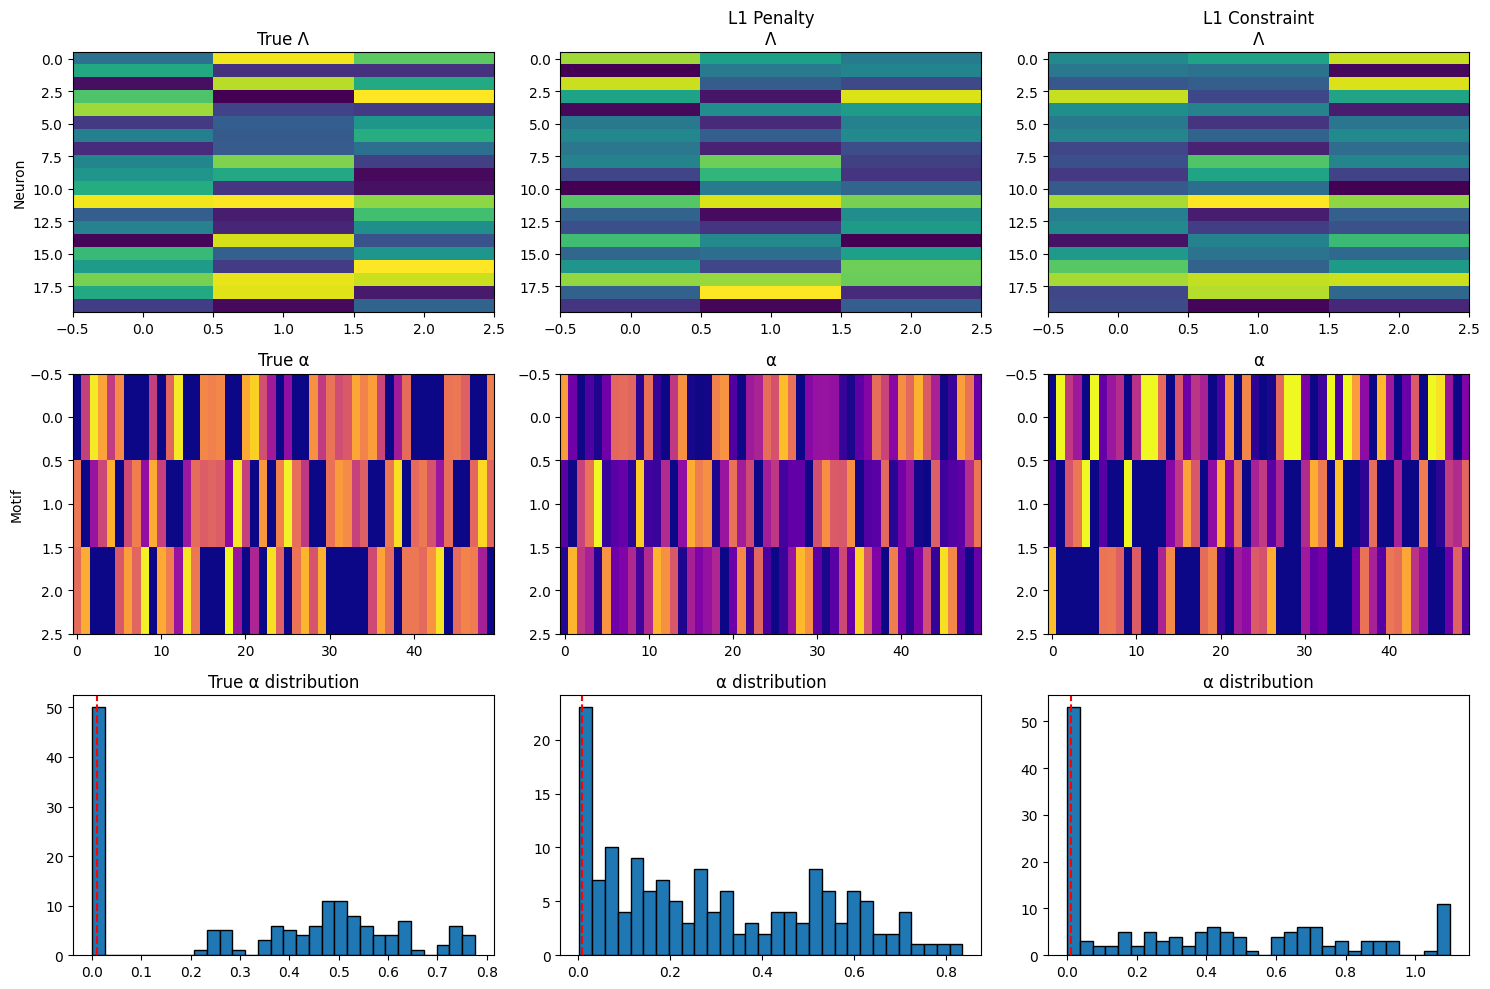


SUMMARY
Method               Sparsity        Exact Zeros    
--------------------------------------------------
L1 Penalty           8.67%           0.00%          
L1 Constraint        34.67%          34.67%         
True                 33.33%          33.33%         


In [46]:
# =============================================================================
# MAIN: COMPARE BOTH METHODS
# =============================================================================

if __name__ == "__main__":
    # Load data
    Y, Alphas_true, Lambdas_true = load_data("../gendata/simNeural.npz")
    print(f"Data: Y {Y.shape}, Alphas {Alphas_true.shape}, Lambdas {Lambdas_true.shape}")
    print(f"True sparsity: {np.mean(Alphas_true < 0.01):.2%}")
    print()
    
    K = 3
    results = {}
    
    # Method 1: Original penalty-based
    print("\n" + "="*60)
    print("METHOD 1: L1 PENALTY")
    print("="*60)
    Lambda1, Alpha1, losses1 = fit_model_penalty(Y, K, beta=5.0, n_iters=3000)
    Lambda1_aligned, Alpha1_aligned, _ = evaluate(Lambda1, Alpha1, Lambdas_true, Alphas_true, "L1 Penalty (β=5)")
    results['L1 Penalty'] = (Lambda1_aligned, Alpha1_aligned, losses1)
    
    # Method 2: Projected gradient (L1 constraint)
    print("\n" + "="*60)
    print("METHOD 2: PROJECTED GRADIENT (L1 CONSTRAINT)")
    print("="*60)
    # Lambda2, Alpha2, losses2 = fit_model_projected(Y, K, max_l1=1.0, n_iters=3000, lr=0.1) #--- overfitted
    Lambda2, Alpha2, losses2 = fit_model_projected(Y, K, max_l1=1.1, n_iters=5000, lr=0.05)
    Lambda2_aligned, Alpha2_aligned, _ = evaluate(np.array(Lambda2), np.array(Alpha2), Lambdas_true, Alphas_true, "Projected (L1≤1)")
    results['L1 Constraint'] = (Lambda2_aligned, Alpha2_aligned, losses2)
    
    # Plot comparison
    plot_comparison(results, Lambdas_true, Alphas_true)
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"{'Method':<20} {'Sparsity':<15} {'Exact Zeros':<15}")
    print("-"*50)
    for name, (L, A, _) in results.items():
        sparsity = np.mean(A < 0.01)
        exact = np.mean(A == 0)
        print(f"{name:<20} {sparsity:<15.2%} {exact:<15.2%}")
    print(f"{'True':<20} {np.mean(Alphas_true < 0.01):<15.2%} {np.mean(Alphas_true == 0):<15.2%}")